Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [2]:
NAME = "Angelina Podolako"
STUDENT_NUMBER = "s1125886"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Notebooks to make your assignments, it might remove the auto-grading metadata. To prevent this, please copy the answers back into the original notebook.
- Only type your answers in places where asked.   

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You can remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 6


## Deadline: December 19th, 23:59

For this last assignment, we will look at a generated dataset, to simulate an experiment you might be performing (no real cats were harmed in this fictive scenario. Note also that since this is fabricated data generated mostly with some variations of [numpy random](https://numpy.org/doc/2.1/reference/random/generator.html), some of it might not be realistic.). To practice doing your own projects in the future, this assignment will have _no example code_, and we also added in some minor annoyances you might encounter when dealing with real-world data.

If you feel stuck, try looking at the previous assignments you finished.
Since most of the things we will be doing, you have already done before.

To give you more space to work, we have created three cells after each question. You do not need to use all of them, this is just to give you some working space in this Jupyter Notebook environment. If you do not use the cell, empty it up, but don't delete it. 

The data corresponds to the following scenario:

### Exercise 1
Lately, you have been browsing memes on Reddit and found out about the [One Orange Braincell](https://www.reddit.com/r/OneOrangeBraincell/top/?t=all) page, where people post silly pictures of their orange cats while claiming that all orange cats all share one brain cell.
Because of that, you became curious if you could create a model to predict if a cat is intelligent.  You decide to perform a survey, which you create together with your friend who studies veterinary sciences.

You and your friends create some tests that people can perform with their cats and let them fill out some online questionnaire forms. 
Users have to fill in the Cat color (Orange, Tabby, Tuxedo or Calico) and Weight in kg.
Then, they have to rate their cats on a scale of 1 to 10 on Playfulness, Curiosity, Affection, and Energy levels and estimate the hours spent outdoors per day.
You let the participants self-assess some experiments, where they have to measure puzzle-solving time (minutes), reaction time (seconds), and toy retrieval success rate (percentage). 
And lastly, you let the users self assess if their cat is intelligent or not, which will also be the value you will predict. **This is a boolean value**.


There might be other values included as well, which might be considered _data leakage_, so please inspect it carefully.

You make your post on the One Orange Braincell subreddit, explaining to participants how to do those experiments and asking them to help you out. 

Luckily for you, your post went viral, and around 700 friendly Redditors performed the experiments and filled in your form. Thanks to this, you end up with the following dataset: `cat_data_reddit.csv`


First, think about collecting data from an online forum like Reddit. What kind of problems do you foresee? Think about people not taking your question seriously, or people feeling like these experiments are too hard. 

People may give inaccurate data, for example, because they did experiments without taking them seriously, or fill in the data altogether as a joke. It may seem funny to someone to enter data such as the weight of a cat 100,000 kg. Someone may not fill in all the data for some reason, as well as not understanding the question or not wanting to share certain information, because in such a forum it is not entirely clear how the information will be processed.

As on the contrary, someone will want to show that his cat is the coolest, and will enter too good data, or even real data, but conducting the experiment several times will have better results.

Moreover, the same user, indeed, for some reason, can give data about the same cat several times.
And people can just conduct an experiment not exactly what will cause distorted data. There may be biased assessments regarding ratings such as smart, playful, etc..

### Exercise 1.1

Load in the dataset using Pandas, and try doing some data exploration. Use, for example, [Box plots](https://seaborn.pydata.org/generated/seaborn.boxplot.html) to get more insight.

We loaded in some packages for you. Please, only include packages we have used before in assignments (so for example, anything in sklearn is fine, but don't import something like Pytorch)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# YOUR CODE HERE
data = pd.read_csv('cat_data_reddit.csv')

print(data.head())
print(data.info())
print(data.shape)
print(data.isnull().sum())
print(data.describe())

     Type  Age    Energy  Playfulness  Curiosity  Affection  Outdoor Time  \
0  Orange   12  5.302873     4.200594   4.690533   6.450056      4.630354   
1  Orange    2  7.536014     7.345078   7.984864   1.640071      7.046873   
2  Orange    1  5.442175     4.425032   5.229776   4.546628      7.335820   
3  Calico   12  6.536085     8.238550   6.630221   3.426528      8.112876   
4  Orange   14  2.748615     1.110428   1.000000   8.564161      3.713343   

   Interaction Time    Weight  Puzzle Time  Reaction Time  Retrieval Rate  \
0          3.862322  3.831680    23.781383       3.615982       88.687282   
1          1.204696  4.121097    12.280801       2.397626      100.000000   
2          2.295253  3.986897    25.267545       2.553870       86.245209   
3          1.793551  5.382176    15.604169       1.107002      100.000000   
4          5.000000  5.543616    30.000000       3.041165       57.382498   

   Intelligent  Intelligence  
0        False     78.890056  
1        Fal

In [9]:
# YOUR CODE HERE
data_dummy_type = pd.get_dummies(data, columns=['Type'], drop_first=False) #Commented since I did it already, but uncomment for first time to use
print(data_dummy_type.head())

data_dummy_type = data_dummy_type.fillna(data_dummy_type.mean())
print(data.isnull().sum())


   Age    Energy  Playfulness  Curiosity  Affection  Outdoor Time  \
0   12  5.302873     4.200594   4.690533   6.450056      4.630354   
1    2  7.536014     7.345078   7.984864   1.640071      7.046873   
2    1  5.442175     4.425032   5.229776   4.546628      7.335820   
3   12  6.536085     8.238550   6.630221   3.426528      8.112876   
4   14  2.748615     1.110428   1.000000   8.564161      3.713343   

   Interaction Time    Weight  Puzzle Time  Reaction Time  Retrieval Rate  \
0          3.862322  3.831680    23.781383       3.615982       88.687282   
1          1.204696  4.121097    12.280801       2.397626      100.000000   
2          2.295253  3.986897    25.267545       2.553870       86.245209   
3          1.793551  5.382176    15.604169       1.107002      100.000000   
4          5.000000  5.543616    30.000000       3.041165       57.382498   

   Intelligent  Intelligence  Type_Calico  Type_Orange  Type_Tabby  \
0        False     78.890056        False         Tr

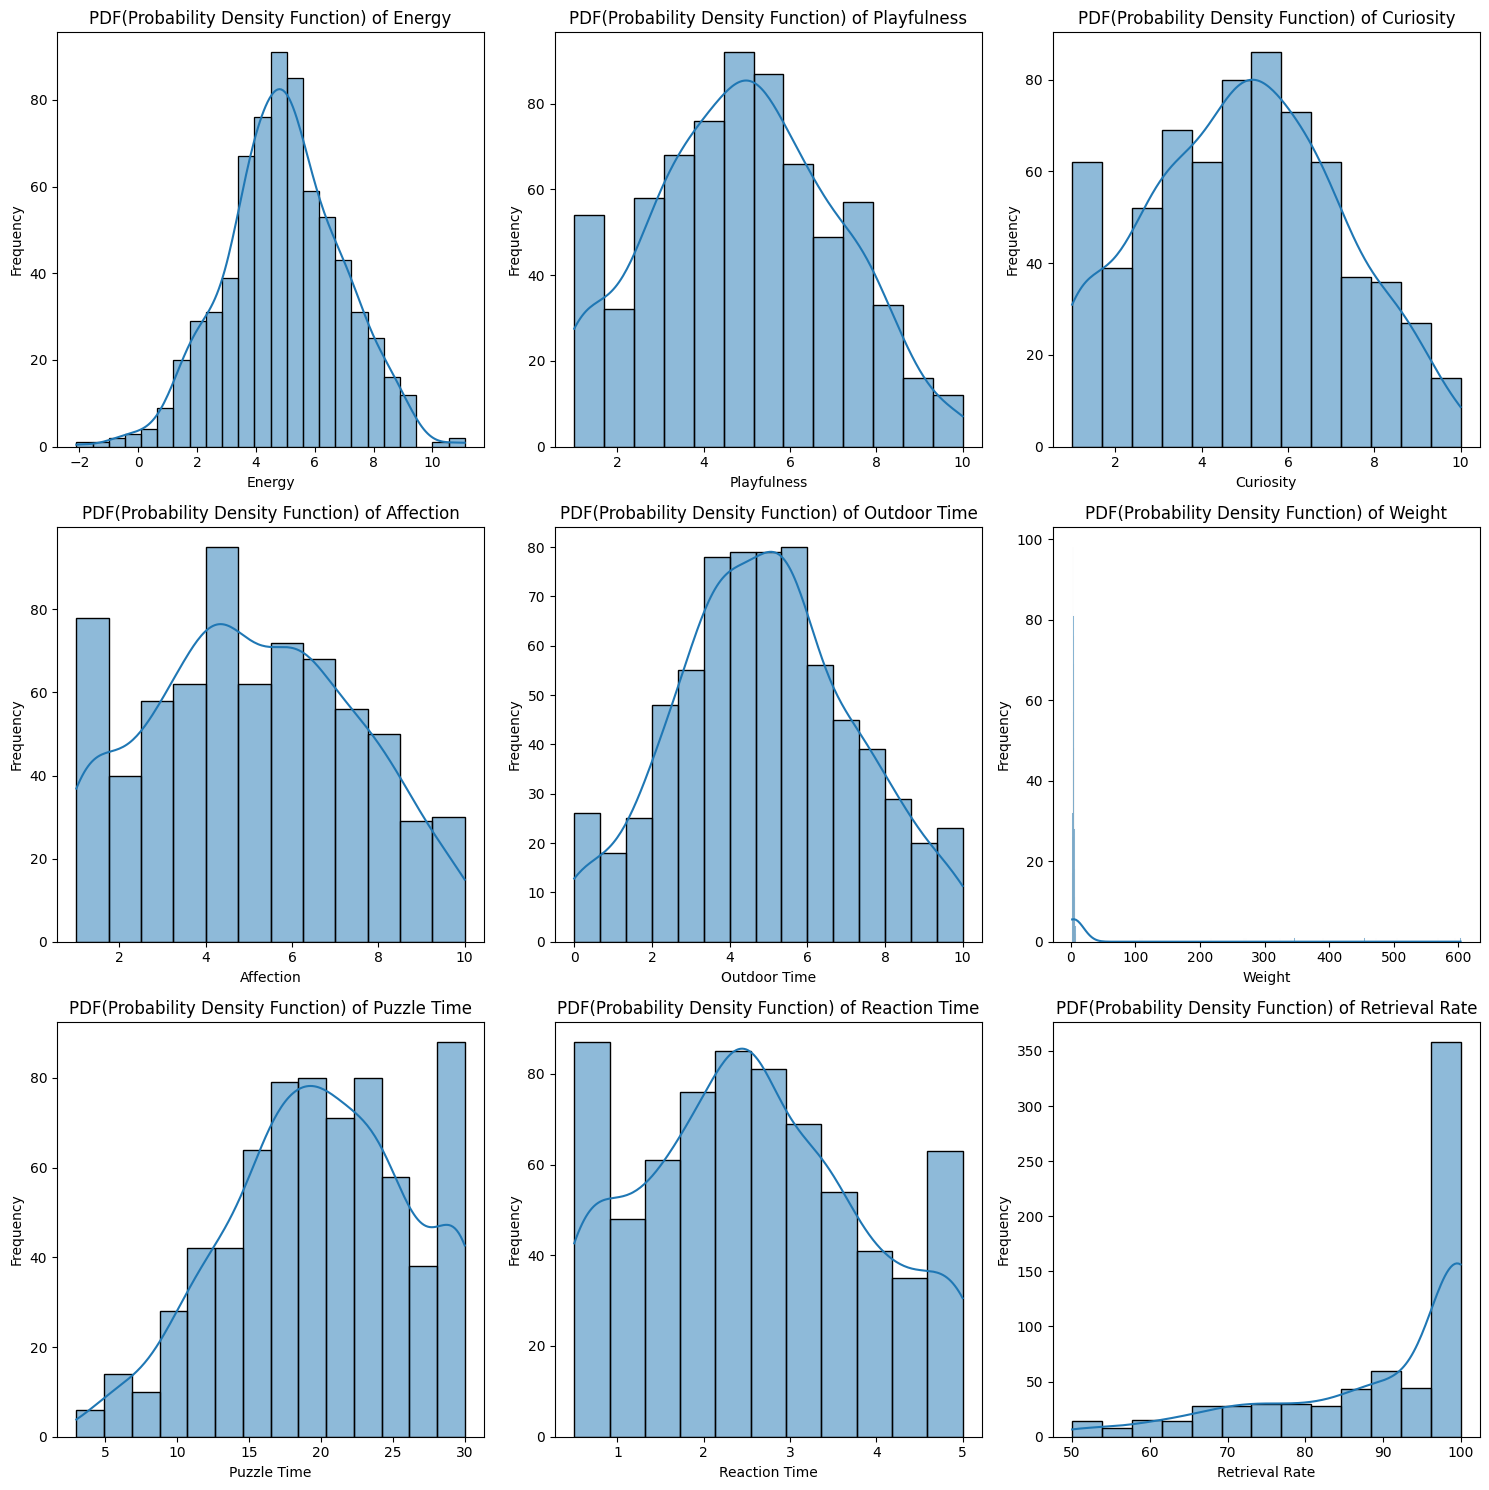

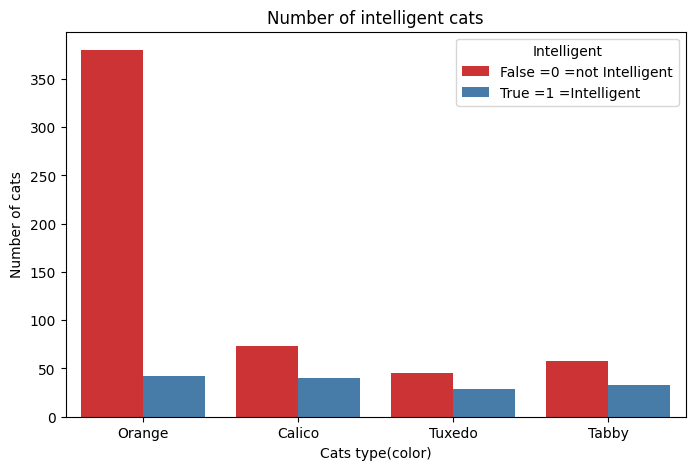

In [10]:
# YOUR CODE HERE
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) #to do not see warnings are not very relevant to me right now

numerical_columns = ['Energy', 'Playfulness', 'Curiosity', 'Affection', 'Outdoor Time',
                     'Weight',
                     'Puzzle Time', 'Reaction Time', 'Retrieval Rate']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(data_dummy_type[col], kde=True, ax=axes[i])  #KDE histograms - distribution of data
    axes[i].set_title(f'PDF(Probability Density Function) of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

type = ['Type_Calico', 'Type_Orange', 'Type_Tabby', 'Type_Tuxedo']

plt.figure(figsize=(8, 5))
sns.countplot(x='Type', hue='Intelligent', data=data, palette='Set1')

plt.title('Number of intelligent cats')
plt.xlabel('Cats type(color)')
plt.ylabel('Number of cats')
plt.legend(title='Intelligent', labels=['False =0 =not Intelligent', 'True =1 =Intelligent'])

plt.show()

### Exercise 1.2

Do some more data exploration to get more understanding of how Intelligent relates to the other features. Which features seem to be most correlated with Intelligent?

(PS: If there is a column perfectly correlated, this might be thanks to data leakage. You might not want to use it for training. )

(PPS: If you use the sns pairplots for this, please limit the number of variables by defining some `plotvars` as a list of column names, and using  `x_vars=plotvars`, `y_vars = plotvars`. If you use all features, the plots get really big and this might crash your TA's machine while grading. If the plot takes longer than 3 seconds to generate, it's too big. )

Features most correlated with 'Intelligent':

Intelligent         1.000000
Intelligence        0.679439
Playfulness         0.388273
Curiosity           0.380454
Energy              0.328358
Retrieval Rate      0.327520
Outdoor Time        0.295546
Type_Calico         0.160934
Type_Tuxedo         0.158356
Type_Tabby          0.150065
Weight              0.101412
Age                 0.065650
Reaction Time      -0.300384
Type_Orange        -0.323660
Affection          -0.358724
Interaction Time   -0.363494
Puzzle Time        -0.386180
Name: Intelligent, dtype: float64

Top 5 features most correlated with 'Intelligent':
 Index(['Intelligence', 'Playfulness', 'Curiosity', 'Energy', 'Retrieval Rate'], dtype='object')


<Figure size 1000x800 with 0 Axes>

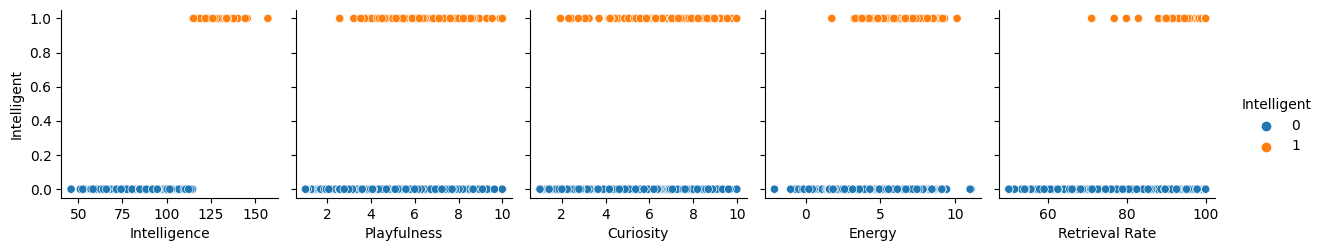

In [12]:
# YOUR CODE HERE

data_dummy_type['Intelligent'] = data_dummy_type['Intelligent'].astype(int)# Convert 'Intelligent' to 1 or 0 (True = 1, False = 0) to int

# Check correlations with Intelligent to identify the most correlated features
correlations_with_intelligent = data_dummy_type.corr()['Intelligent'].sort_values(ascending=False)
print("Features most correlated with 'Intelligent':\n")
print(correlations_with_intelligent)

# Select top correlated features (excl Intelligent)
top_features  = correlations_with_intelligent.index[1:6]  # top 5 features most correlated with 'Intelligent'
print("\nTop 5 features most correlated with 'Intelligent':\n", top_features)
      
plt.figure(figsize=(10, 8))
sns.pairplot(data_dummy_type, hue='Intelligent', x_vars=top_features, y_vars=['Intelligent'])
plt.show() 

In [13]:
# YOUR CODE HERE

In [14]:
# YOUR CODE HERE



**Answer below, which features seem correlated with Intelligent?:**

Top 5 features most correlated with 'Intelligent': Playfulness, Curiosity, Energy, Retrieval Rate, Outdoor Time

### Exercise 1.3

Do some more data analysis where you look at the relation of the different cat types in the data. Do you see any differences in distribution between the different cat types?

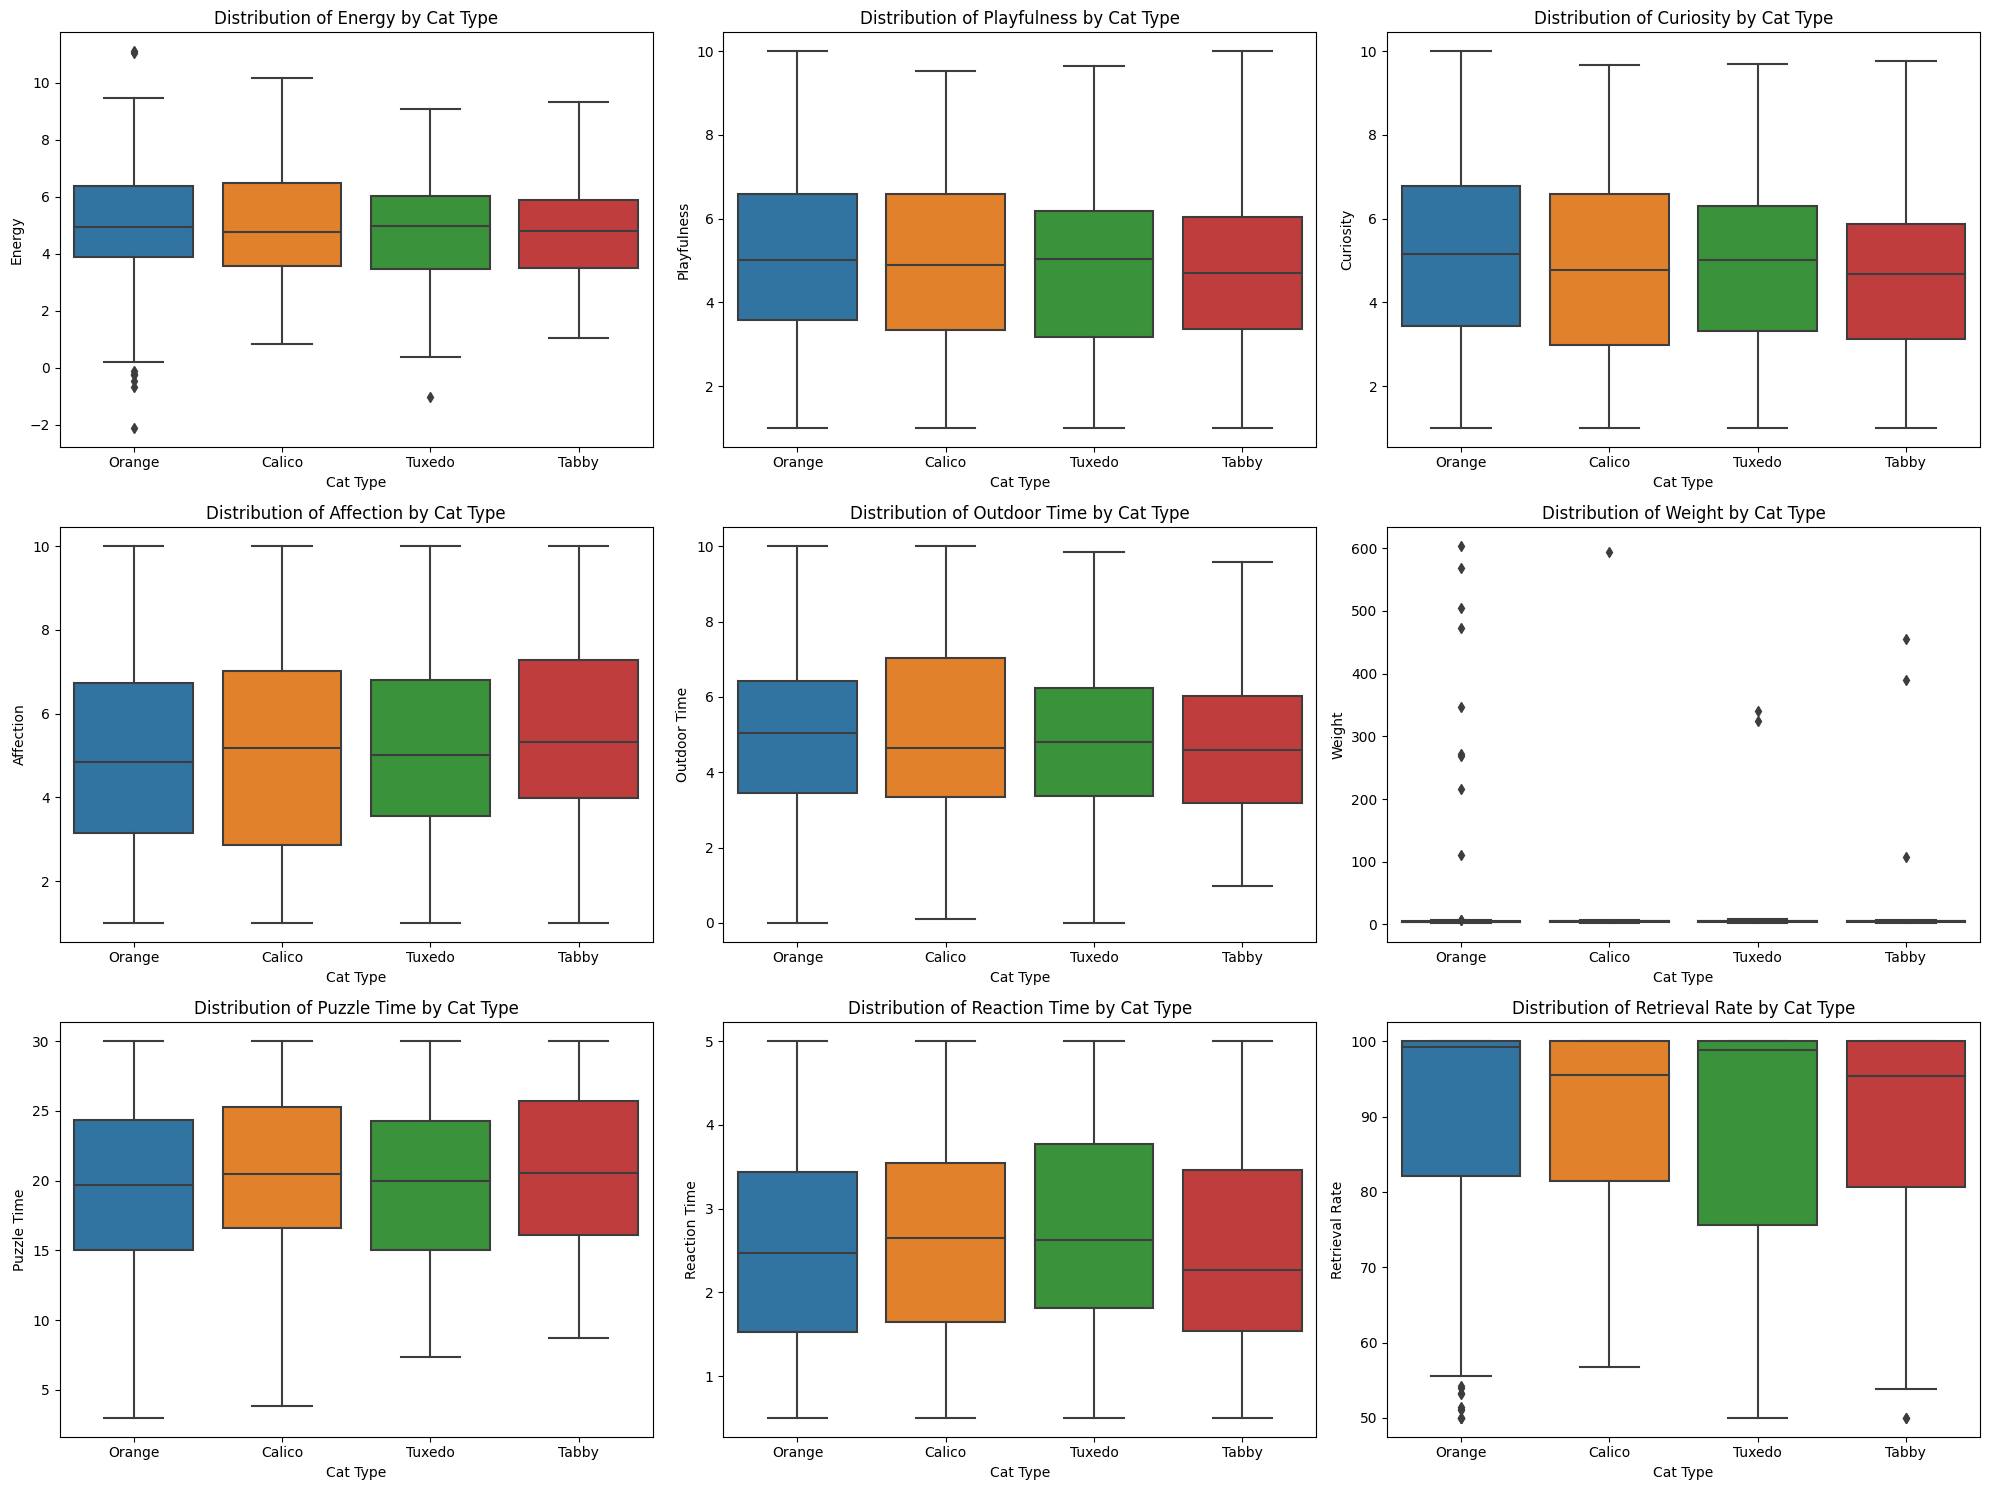

In [18]:
# YOUR CODE HERE

plt.figure(figsize=(20, 15))  

for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)  
    sns.boxplot(x='Type', y=col, data=data)
    plt.title(f'Distribution of {col} by Cat Type')
    plt.xlabel('Cat Type')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

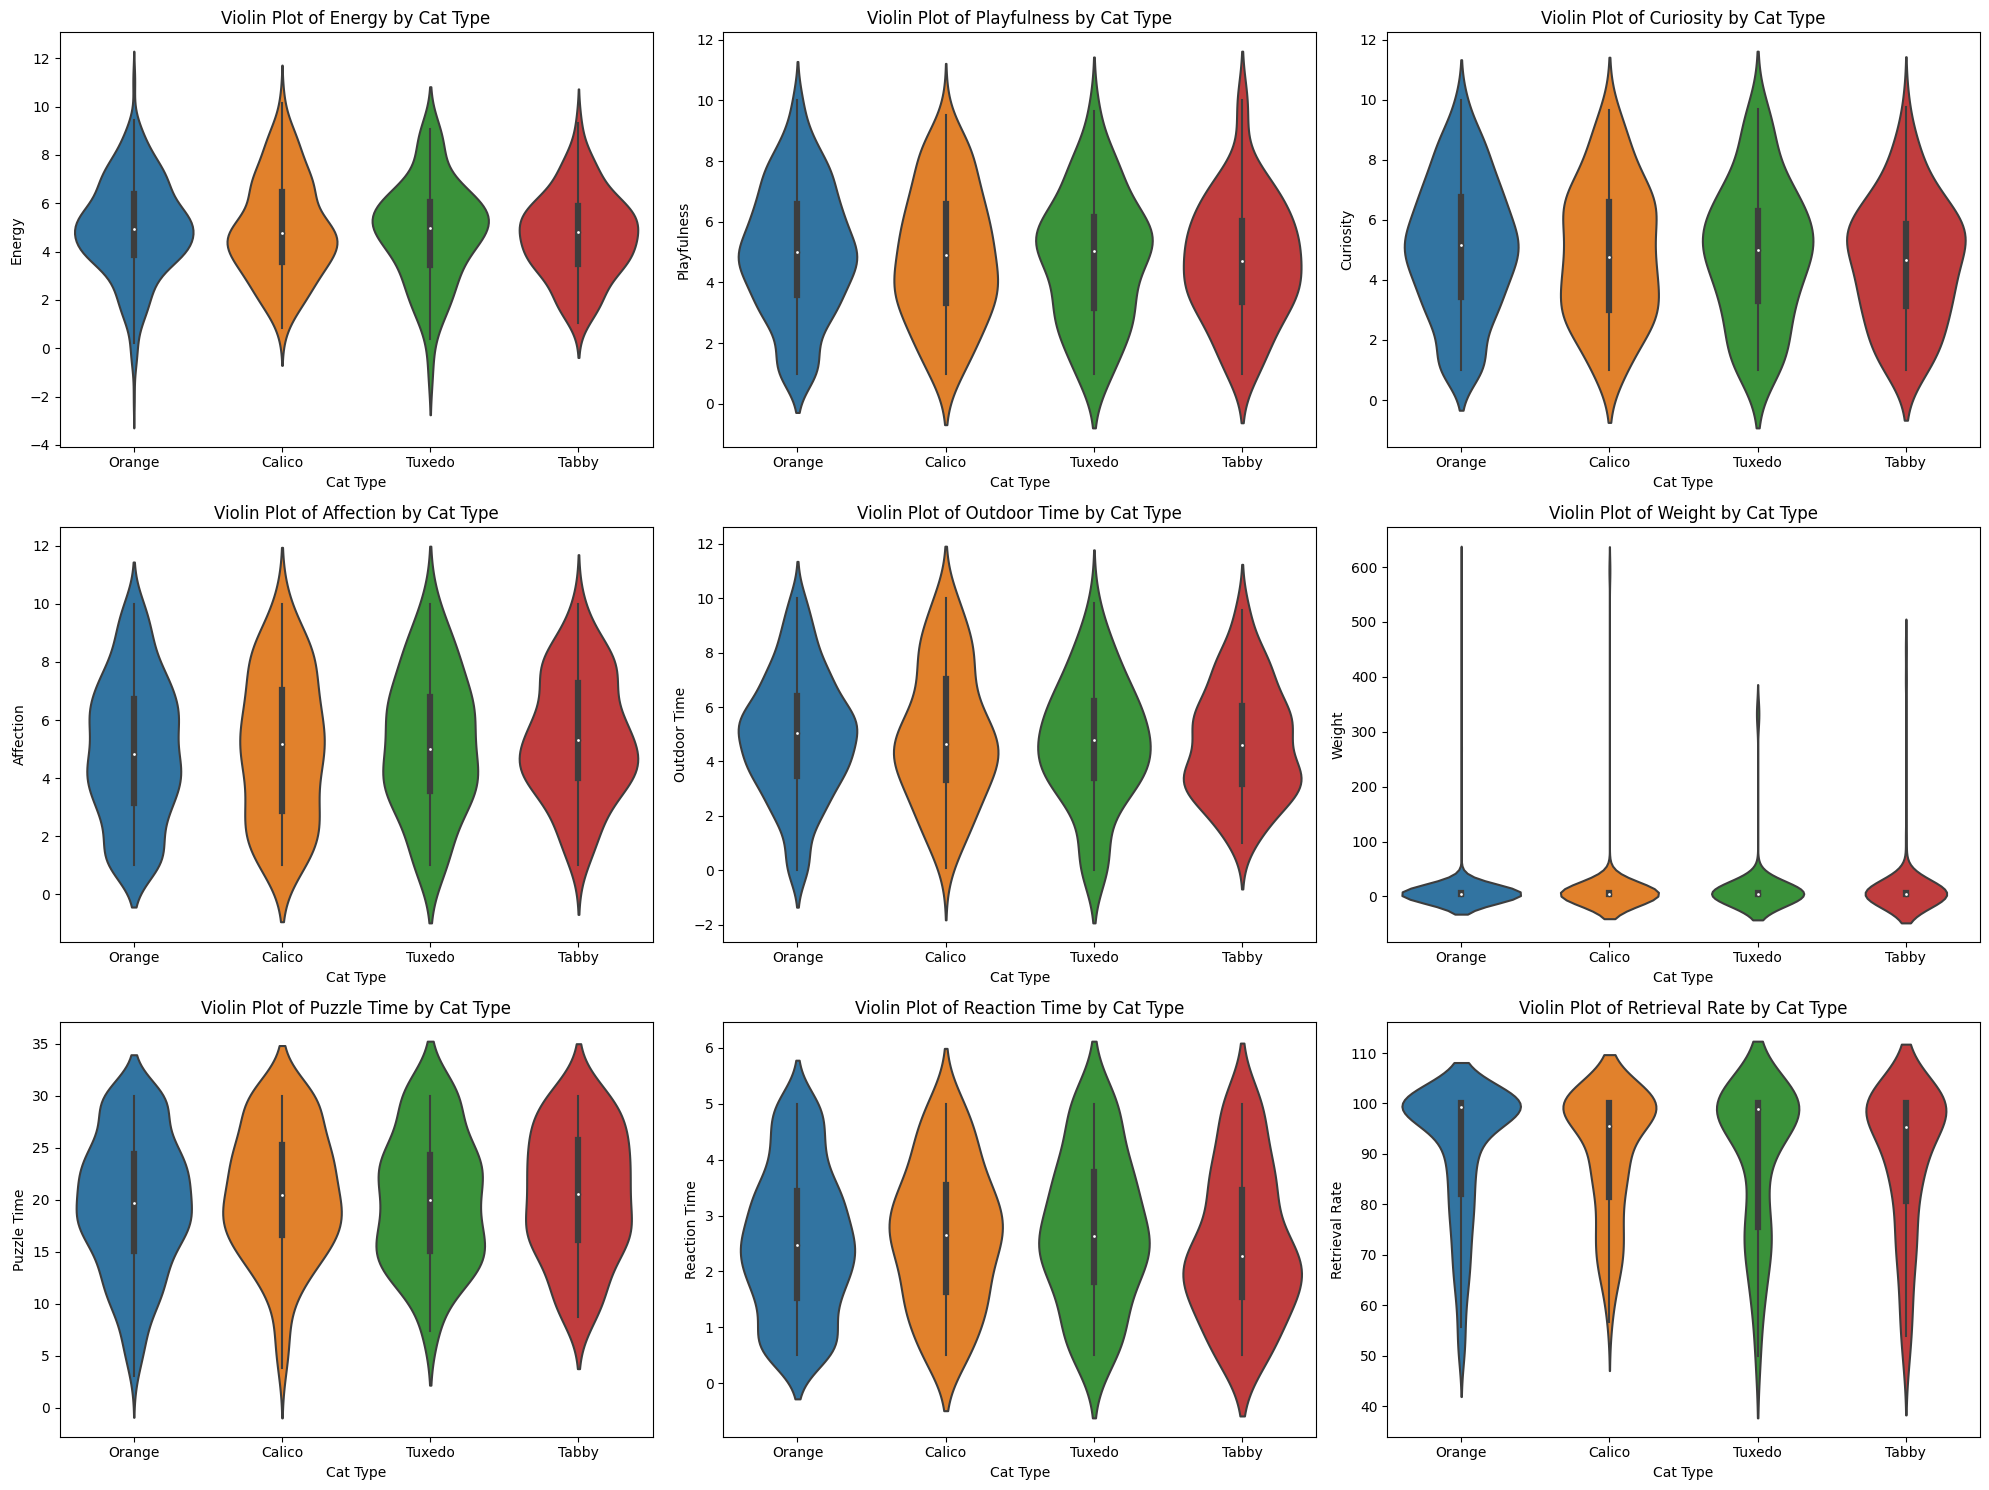

In [19]:
# YOUR CODE HERE
plt.figure(figsize=(20, 15))

for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.violinplot(x='Type', y=col, data=data)
    plt.title(f'Violin Plot of {col} by Cat Type')
    plt.xlabel('Cat Type')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [20]:
# YOUR CODE HERE


**Answer below, what seems to be the difference in cat types?:**

YOUR ANSWER HERE

### Exercise 1.4

Uh oh, as a side effect of performing this experiment on the internet, it looks like some participants filled in the survey without taking it seriously. Take a look at the Weights column and use it to find values that are probably not realistic.

Remove these from your dataset.

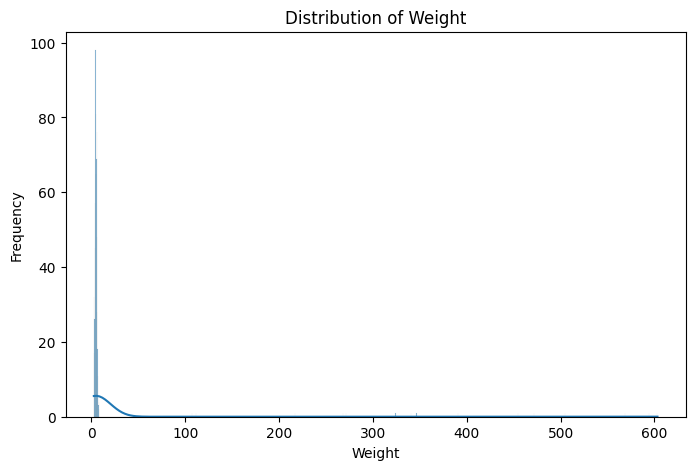

In [24]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))
sns.histplot(data_dummy_type['Weight'], kde=True)
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

In [25]:
# YOUR CODE HERE

lower_bound = 1  # min
upper_bound = 20  #max

data_cleaned_with_dummy = data_dummy_type[(data_dummy_type['Weight'] >= lower_bound) & (data_dummy_type['Weight'] <= upper_bound)]
print(f'Original data: {data_dummy_type.shape}')
print(f'Sfter deleting not realistic data: {data_cleaned_with_dummy.shape}')

Original data: (700, 17)
Sfter deleting not realistic data: (685, 17)


In [26]:
# YOUR CODE HERE

### Exercise 1.5

It seems like you are also dealing with quite a lot of missing data, namely for the following columns:

- 'Puzzle Time'
- 'Reaction Time'
- 'Retrieval Rate'


Try coming up with a way to deal with this missing data.

Next, do any data transformations you deem necessary. Remember that you probably have to do something to deal with categorical features. 

Next, split up your data both in a an array of features (X_train, X_val) and an array of targets (y_train, y_val).
Use any percentage to split into train and validation set. (Go back to lecture 3 if you forgot what a validation set is.)

Again, make sure you do not introduce accidental data leakage in your train data. 

In [28]:
# YOUR CODE HERE
#missing_values =  data_dummy_type.isnull().sum() #Puzzle Time=15; Reaction Time=15;  Retrieval Rate=15 - WAS BEFORE DID FILLNA BY MEAN
#print(missing_values)

In [29]:
# YOUR CODE HERE
X = data_cleaned_with_dummy.drop(columns=['Intelligent'])  # excl Intelligence
y = data_cleaned_with_dummy['Intelligent']  # target var

print(X.head())
print(y.head())

   Age    Energy  Playfulness  Curiosity  Affection  Outdoor Time  \
0   12  5.302873     4.200594   4.690533   6.450056      4.630354   
1    2  7.536014     7.345078   7.984864   1.640071      7.046873   
2    1  5.442175     4.425032   5.229776   4.546628      7.335820   
3   12  6.536085     8.238550   6.630221   3.426528      8.112876   
4   14  2.748615     1.110428   1.000000   8.564161      3.713343   

   Interaction Time    Weight  Puzzle Time  Reaction Time  Retrieval Rate  \
0          3.862322  3.831680    23.781383       3.615982       88.687282   
1          1.204696  4.121097    12.280801       2.397626      100.000000   
2          2.295253  3.986897    25.267545       2.553870       86.245209   
3          1.793551  5.382176    15.604169       1.107002      100.000000   
4          5.000000  5.543616    30.000000       3.041165       57.382498   

   Intelligence  Type_Calico  Type_Orange  Type_Tabby  Type_Tuxedo  
0     78.890056        False         True       False

In [30]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Тest: {X_test.shape}, {y_test.shape}")

Train: (548, 16), (548,)
Тest: (137, 16), (137,)


### Exercise 1.6

We are going to fit a model on this dataset. Pick any of the models we have seen before. 
We would recommend to start with something that is easy and gives you as much insight as possible in which features are important. 

Explore your results and find out which features are most important for predicting cat intelligence. 

After you have done this, evaluate on the validation set. Use any metric you think makes sense. Try seeing if you can tell any difference on the performance on orange cats and the other cats.

What do you observe?

In [32]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
y_pred = linear_model.fit(X_train, y_train).predict(X_test)


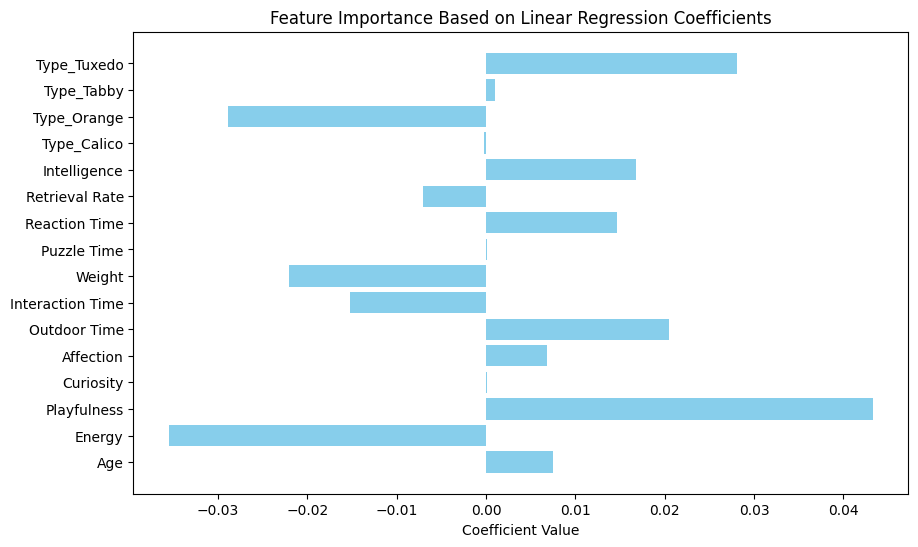

In [33]:
# YOUR CODE HERE
coefficients = linear_model.coef_
feature_names = X_train.columns 

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients, color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance Based on Linear Regression Coefficients')
plt.show()

In [34]:
# YOUR CODE HERE
from sklearn.metrics import mean_squared_error, r2_score
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Calculate R² score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.07832385133638615
R² Score: 0.4579423430189412


**Answer below, what are the most important features for predicting intelligent? What do you observe when evaluating on the validation set?**

Features:  
Type = Tuxedo, Intelligence(understandable), Playfulness, Outdoor time, Reaxtion time  
Evaluation:  
Low MSE means that modelš predictions are clode to true values.  
R^2 = 1 if prefectly fits data and =0 if model better than simply prediting mean value
So, overall I think that workd pretty good.

# Exercise 1.7

Your veterinarian friend, who also volunteers at a kennel, decides to also perform an experiment on cats themselves. They mentioned they might be able to use this information at the cat kennel to put on the possible adoption pages for cats. Your friend is very diligent and collects the data of 300 cats, with no missing values and all values being realistic. You can expect this data is very accurate.

Do some data exploration on this data, can you find differences between this data and the Reddit data?

In [38]:
# YOUR CODE HERE
data_vet = pd.read_csv('cat_data_veterinary_friend.csv')

print(data_vet.head())
print(data_vet.info())
print(data_vet.shape)
print(data_vet.isnull().sum())
print(data_vet.describe())

     Type  Age    Energy  Playfulness  Curiosity  Affection  Outdoor Time  \
0   Tabby   10  5.430611     4.405451   4.027791   5.573022      3.987735   
1  Orange    5  2.696889     1.534628   2.546194   9.093610      4.513177   
2   Tabby    1  6.282088     6.018382   3.967935   5.354445      6.840063   
3   Tabby    8  6.649553     7.925794   7.635289   2.494394      8.212888   
4  Orange    1  5.880008     4.713693   4.884315   4.282749      6.050132   

   Interaction Time    Weight    puzzzle  reaction   retrieval  Intelligent  \
0          3.764701  4.342069  22.050302  4.041454   85.088981            1   
1          5.000000  5.323447  28.571650  5.000000   61.309417            1   
2          3.250385  4.433586  25.757843  2.578869  100.000000            1   
3          1.732507  5.219725  23.078283  0.609182  100.000000            1   
4          2.765362  2.771282  21.525333  2.721140  100.000000            0   

   Intelligence  
0         False  
1         False  
2       

In [39]:
# YOUR CODE HERE

In [40]:
# YOUR CODE HERE

### Exercise 1.8

Uh oh, it seems like, since your friend manually filled out all the questionnaire results in an Excel spreadsheet, the columns have different names than the ones you collected from Reddit. Try to compare the column names of your Reddit dataset and of your friend's dataset, and change the names so that they match up with the Reddit dataset, and use this to make `X_test` and `y_test`


In [42]:
# YOUR CODE HERE
print("Reddit: ", data.columns)
print("Vet friend: ", data_vet.columns)

Reddit:  Index(['Type', 'Age', 'Energy', 'Playfulness', 'Curiosity', 'Affection',
       'Outdoor Time', 'Interaction Time', 'Weight', 'Puzzle Time',
       'Reaction Time', 'Retrieval Rate', 'Intelligent', 'Intelligence'],
      dtype='object')
Vet friend:  Index(['Type', 'Age', 'Energy', 'Playfulness', 'Curiosity', 'Affection',
       'Outdoor Time', 'Interaction Time', 'Weight', 'puzzzle', 'reaction',
       'retrieval', 'Intelligent', 'Intelligence'],
      dtype='object')


In [43]:
# YOUR CODE HERE

rename_columns = {
    'puzzzle': 'Puzzle_Time',
    'reaction': 'Reaction_Time',
    'retrieval': 'Retrieval_Rate'
}
data_vet.rename(columns=rename_columns, inplace=True)

print(data_vet.columns)

Index(['Type', 'Age', 'Energy', 'Playfulness', 'Curiosity', 'Affection',
       'Outdoor Time', 'Interaction Time', 'Weight', 'Puzzle_Time',
       'Reaction_Time', 'Retrieval_Rate', 'Intelligent', 'Intelligence'],
      dtype='object')


In [44]:
# YOUR CODE HERE
X_test  = data_cleaned_with_dummy.drop(columns=['Intelligent'])  # excl Intelligence
y_test  = data_cleaned_with_dummy['Intelligent']  # target var

print(X_test.head())
print(y_test.head())

   Age    Energy  Playfulness  Curiosity  Affection  Outdoor Time  \
0   12  5.302873     4.200594   4.690533   6.450056      4.630354   
1    2  7.536014     7.345078   7.984864   1.640071      7.046873   
2    1  5.442175     4.425032   5.229776   4.546628      7.335820   
3   12  6.536085     8.238550   6.630221   3.426528      8.112876   
4   14  2.748615     1.110428   1.000000   8.564161      3.713343   

   Interaction Time    Weight  Puzzle Time  Reaction Time  Retrieval Rate  \
0          3.862322  3.831680    23.781383       3.615982       88.687282   
1          1.204696  4.121097    12.280801       2.397626      100.000000   
2          2.295253  3.986897    25.267545       2.553870       86.245209   
3          1.793551  5.382176    15.604169       1.107002      100.000000   
4          5.000000  5.543616    30.000000       3.041165       57.382498   

   Intelligence  Type_Calico  Type_Orange  Type_Tabby  Type_Tuxedo  
0     78.890056        False         True       False

### Exercise 1.9

Use your model to predict the intelligence of the dataset your friend made. Perform evaluation, where you look both at the performance of orange cats and at other cats.

What do you notice? How can this be explained?

In [46]:
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X_test, y_test, test_size=0.2, random_state=42)

y_pred = linear_model.fit(X_train, y_train).predict(X_test)



In [47]:
# YOUR CODE HERE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Calculate R² score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.07832385133638615
R² Score: 0.4579423430189412


In [48]:
# YOUR CODE HERE

**Answer below, what do you notice about your prediction? Compare the prediction on the test test (the dataset you just loaded in) and the validation set.**

I think both models work about the same way here, because I used the simplest linear model, and also because they most likely used the same data or similar, just the veterinarian's data in a smaller volume.

### Exercise 1.10

Frustrated with your results above, you try fitting a more complicated model. Try picking any of the more advance models we talked about during the lectures (Maybe SVM, Random Forest, AdaBoost or GradientBoost), and try evaluating again, both on validation and test set.

Are you satisfied with the results now?

In [52]:
# YOUR CODE HERE
from sklearn.ensemble import AdaBoostClassifier

ada_boost_model = AdaBoostClassifier(random_state=42)

ada_boost_model.fit(X_train, y_train)

y_pred = ada_boost_model.predict(X_test)


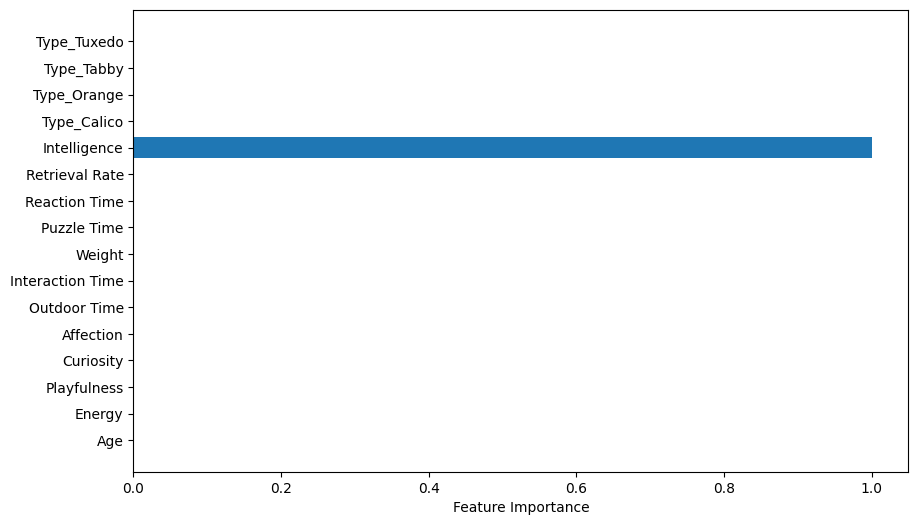

In [53]:
# YOUR CODE HERE
feature_importances = ada_boost_model.feature_importances_
feature_names = X_train.columns 

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.show()

In [54]:
# YOUR CODE HERE
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

print(f"{confusion_matrix(y_test, y_pred)}")
print(f"Accuracy score of {accuracy_score(y_test, y_pred)}")

[[113   0]
 [  0  24]]
Accuracy score of 1.0


**Answer below, what are the most important features now? What do you notice about your prediction on both validation and test set?**

Only Intelligence is important now. I am very happy with the results I see

### Exercise 1.11

It seems like some bias leaked in during the data collection on Reddit. Try thinking about how bias occurred when conducting a survey. What kind of bias do you think showed up, and why? What surprised you when comparing the results, both on the validation and test set?

If you were conducting this experiment in real life, what would you change?

Types of Biases:  
1)Sampling bias: Reddit data may represent certain types of cats (for example, more popular ones which people have)
2)Observer Bias: Reddit users could subjectively evaluate intelligence (everyone loves its cat!!!)

Improvements:
1)Collecting a representative sample from different sources (Not only reddit)
2)Standardization of intelligence assessments (objective tests)
3)Increasing the sample size (But I think it is alrwady not small, but more data - more precide model(I hope))

Exercise inspired by Emma's cat Mochi. He's wishing you the best on finishing the assignment, and a nice holiday!

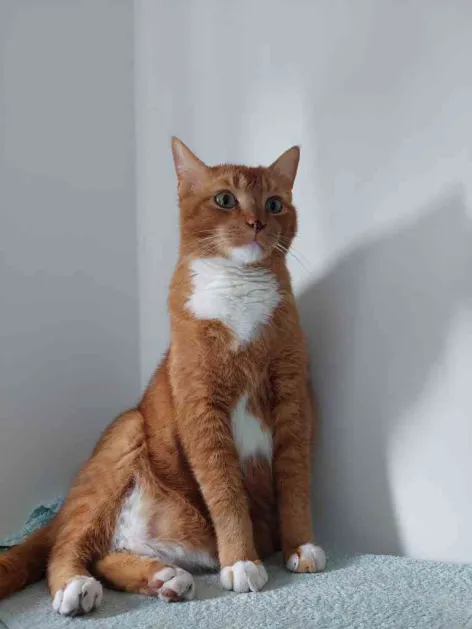
